In [2]:
# Step 0: Importing the functions

# Tudat imports for propagation and estimation
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup, parameters_setup, simulator
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, observable_models, observations_setup, observations, estimation_analysis
from tudatpy.astro.time_representation import DateTime

# import MPC interface
from tudatpy.data.mpc import BatchMPC

# import SBDB interface
from tudatpy.data.sbdb import SBDBquery

# other useful modules
import numpy as np
import datetime

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# additional things for the asteroids
from tudatpy import constants
import os           # for the extraction of asteroid kernels
# from astroquery.jplhorizons import Horizons     # for extracting Cartesian coordinates


# Load SPICE Kernel
# SPICE KERNELS
spice.load_standard_kernels()

In [27]:
# Step 1: Set constants

# Setting some constants
# target_mpc_code_list = [433]       # Eros
# The 9 asteroids
target_mpc_code_list = [1566, 66146, 66391, 437844, 137924, 138127, 480883, 468468, 364136]
# target_mpc_code_list = [ 66146]

observations_start = datetime.datetime(2018, 1, 1)
observations_end = datetime.datetime(2023, 1, 1)

# number of iterations for our estimation
number_of_pod_iterations = 6

# timestep of 20 hours for our estimation
timestep_global = 20 * 3600.0

# 1 month time buffer used to avoid interpolation errors:
time_buffer = 1 * 31 * 86400.0

# define the frame origin and orientation.
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

In [4]:
target_name_list = []
target_spkid_list = []

for id in target_mpc_code_list:
    target_sbdb_id = SBDBquery(id)

    target_spkid_element = target_sbdb_id.codes_300_spkid

    obj = target_sbdb_id.query.get("object", {})
    # print(obj.keys())

    target_name_element = (
        obj.get("shortname")
        or obj.get("fullname")
        or obj.get("des")
        or str(id)
    )

    target_name_list.append(target_name_element)
    target_spkid_list.append(target_spkid_element)

    print(f"SPK ID for {target_name_element} is: {target_spkid_element}")

SPK ID for 433 Eros is: Eros


In [5]:
# Step 3: Pulling out data from the Batch / retrieving data

batch = BatchMPC()

batch.get_observations(target_mpc_code_list)
batch.filter(
    epoch_start = observations_start,
    epoch_end = observations_end,
)

batch.summary()


   Batch Summary:
1. Batch includes 1 minor planets:
   ['433']
2. Batch includes 2935 observations, including 1707 observations from space telescopes
3. The observations range from 2018-05-01 03:22:18.336012 to 2021-12-02 02:25:42.815986
   In seconds TDB since J2000: 578417007.5214744 to 691684011.9990752
   In Julian Days: 2458239.64049 to 2459550.60119
4. The batch contains observations from 52 observatories, including 4 space telescopes



/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:866: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['433' '433' '433' ... '433' '433' '433']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  obs.loc[:, "number"] = obs.number.astype(str)


In [6]:
# Include space-telescopes:

print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Summary of space telescopes in batch:
     Code                                    Name   count
275   275  Non-geocentric Occultation Observation     2.0
1239  C51                                    WISE    83.0
1245  C57                                    TESS  1620.0
1247  C59                              Yangwang-1     2.0


In [7]:
obs_by_WISE = (
    batch.table.query("observatory == 'C51'")
    .loc[:, ["number", "epochUTC", "RA", "DEC"]]
    .iloc[[0, -1]]
)

print("\nInitial and Final Observations by WISE:")
print(obs_by_WISE)


Initial and Final Observations by WISE:
      number                   epochUTC        RA       DEC
10833    433 2018-07-25 00:09:44.063981  0.468337  0.388395
13603    433 2021-08-21 20:25:12.662418  4.499383 -0.466792


In [8]:
# Step 4: Set up the environment:

# List the bodies for our environment
bodies_to_create = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Moon",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune",
]

# Create system of bodies
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation
)

bodies = environment_setup.create_system_of_bodies(body_settings)

# Retrieve Eros' body name from BatchMPC and set its centre to enable its propagation
bodies_to_propagate = batch.MPC_objects
print(bodies_to_propagate)

# Central bodies needs to be as big as bodies_to_propagate
central_bodies = ['SSB'] * len(batch.MPC_objects)

['433']


In [9]:
# Step 5: Convert the observations to Tudat

# We filter out the space based observations
# This is also where we'd add bias settings
# For this example we use: the plain angular position observation settings

# Transform the MPC observations into a tudat compatible format.
# note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None)

# set create angular_position settings for each link in the list.
observation_settings_list = list()
link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings here
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )

# Retrieve the first and final observation epochs and add the buffer
epoch_start_nobuffer = batch.epoch_start
epoch_end_nobuffer = batch.epoch_end

# epoch_start_nobuffer = DateTime.from_epoch(batch.epoch_start)
# epoch_end_nobuffer =  DateTime.from_epoch(batch.epoch_end)

epoch_start_buffer = epoch_start_nobuffer - time_buffer
epoch_end_buffer = epoch_end_nobuffer + time_buffer

/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:147: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  bias_dataframe = bias_dataframe.stack(level=0)


In [10]:
# print(f"Epoch Start (no buffer): {epoch_start_nobuffer.to_epoch()}")
# print(f"Epoch End (no buffer): {epoch_end_nobuffer.to_epoch()}")
print("--------------------------------------------------")
print(f"Epoch Start (no buffer): {epoch_start_nobuffer}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer}")
print("--------------------------------------------------")
print(f"Epoch Start (buffer): {epoch_start_buffer}")
print(f"Epoch End (buffer): {epoch_end_buffer}")

--------------------------------------------------
Epoch Start (no buffer): 578417007.5214744
Epoch End (no buffer): 691684011.9990752
--------------------------------------------------
Epoch Start (buffer): 575738607.5214744
Epoch End (buffer): 694362411.9990752


In [11]:
# Step 6: Create the acceleration settings

# Define accelerations
accelerations = {
    "Sun": [
        propagation_setup.acceleration.point_mass_gravity(),
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Moon": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# Set up the accelerations settings for each body, in this case only Eros
acceleration_settings = {}
for body in batch.MPC_objects:
    acceleration_settings[str(body)] = accelerations

# create the acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_settings, bodies_to_propagate, central_bodies
)

In [12]:
# # Step 7.5: Extract the ephemeris for the 9 asteroids
# # From my local kenrel

# # Extract the ephemeris for the target asteroids for the initial guess

# kernel_directory_21_asteroids = "/home/emmabob/Bachelor_Project/asteroid_kernels/9_asteroids_SPK" 

In [13]:
# print(target_spkid_list)
# target_spk_local_kernel = ['20001566', '20066146', '20066391', '20437844', '20137924', '20138127', '20480883', '20468468', '20364136']

In [14]:
# # Loop through the dictionary and load the corresponding .bsp file
# for name, id in zip(target_name_list, target_spk_local_kernel):
    
#     # Calculate the NAIF ID from the data list
#     # E.g. Juno has 20000003 (ID: 3)
#     naif_id = int(id)
    
#     # Then extract the ephemeris for each asteroid
#     kernel_path = os.path.join(kernel_directory_21_asteroids, f"{naif_id}.bsp")
#     if os.path.exists(kernel_path):
#         spice.load_kernel(kernel_path)
#         print(f"Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
#     else:
#         print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")


In [15]:
# Step 7: Retrieve the initial guess for the asteroids

rng = np.random.default_rng(seed=1)

asteroid_states = []

initial_position_offset = 1e6 * 1000
initial_velocity_offset = 100

for spk_id, name in zip(target_spkid_list, target_name_list):

    # 1. Get SPICE initial state
    initial_states = spice.get_body_cartesian_state_at_epoch(
        spk_id,
        global_frame_origin,
        global_frame_orientation,
        "NONE",
        epoch_start_buffer,
    )

    # 2. Create noisy initial guess
    initial_guess = initial_states.copy()
    initial_guess[0:3] += (2 * rng.random(3) - 1) * initial_position_offset
    initial_guess[3:6] += (2 * rng.random(3) - 1) * initial_velocity_offset

    # 3. Store everything in a structured way
    asteroid_states.append({
        "spkid": spk_id,
        "name": name,
        "true_state": initial_states,
        "initial_guess": initial_guess,
        "error": initial_guess - initial_states
    })

    print(f"{name} ({spk_id})")
    print("Error:", asteroid_states[-1]["error"])
    print("-" * 50)

433 Eros (Eros)
Error: [ 2.36432494e+07  9.00927393e+08 -7.11680775e+08  8.97298894e+01
 -3.76337096e+01 -1.53347102e+01]
--------------------------------------------------


In [16]:
# Step 7.75: Create one combined initial guess (6*9 = 54)

combined_initial_guess = np.hstack(
    [obj["initial_guess"] for obj in asteroid_states]
)

print(combined_initial_guess.shape)

(6,)


In [17]:
# Step 8: Finalise the propagation setup

# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)
# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)

# To create propagator:

bodies_to_integrate = [
        obj["name"] for obj in asteroid_states      # Grab all 9 asteroids
    ],

propagator_settings = propagation_setup.propagator.translational(
    central_bodies = central_bodies,
    acceleration_models = acceleration_models,
    bodies_to_integrate = bodies_to_propagate,
    initial_states = combined_initial_guess,        # Grab the (54,) initial guess
    initial_time = epoch_start_buffer,
    integrator_settings = integrator_settings,
    termination_settings = termination_condition,
)



In [18]:
# Step 9: Setting Up the Estimation
# The observation collection, the environment and propagations settings are ready
# Commence estimation

# Here: In this example we will simply estimate the position of the 9 asteroids 
# and as such only include an initial states parameter.

In [19]:
# Setup parameters settings to propagate the state transition matrix
parameter_settings = parameters_setup.initial_states(
    propagator_settings, bodies
)

# Create the parameters that will be estimated
parameters_to_estimate = parameters_setup.create_parameter_set(
    parameter_settings, bodies, propagator_settings
)

# Max iterations was set to 6

# Set up the estimator
estimator = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# provide the observation collection as input, and limit number of iterations for estimation.
pod_input = estimation_analysis.EstimationInput(
    observations_and_times=observation_collection,
    convergence_checker=estimation.estimation_analysis.estimation_convergence_checker(
        maximum_iterations=number_of_pod_iterations,
    ),
)

# Set methodological options
pod_input.define_estimation_settings(reintegrate_variational_equations=True)

In [20]:
print(parameters_to_estimate.parameter_set_size)
print(bodies_to_integrate)
print(observation_collection.concatenated_observations.shape)

6
(['433 Eros'],)
(2456,)


In [21]:
print("Bodies propagated:")
print(bodies_to_integrate)

print("Number of estimated parameters:")
print(parameters_to_estimate.parameter_set_size)

print("Combined state size:")
print(len(combined_initial_guess))

Bodies propagated:
(['433 Eros'],)
Number of estimated parameters:
6
Combined state size:
6


In [22]:
# Step 10: Performing the estimation:

# Perform the estimation
pod_output = estimator.perform_estimation(pod_input)

Calculating residuals and partials 2456
Current residual: 0.0388475
Parameter update-8.79207e+07 -1.00293e+09  8.62669e+08     -89.6507      43.6746      12.4971
Calculating residuals and partials 2456
Current residual: 0.00256741
Parameter update 6.40225e+07   1.0155e+08 -1.50535e+08   -0.0606153     -6.02351      2.79129
Calculating residuals and partials 2456
Current residual: 7.25924e-06
Parameter update    260272     470785    -481993 -0.0185933 -0.0176365  0.0476038
Calculating residuals and partials 2456
Current residual: 1.83321e-06
Parameter update    -5.15896     -2.74777    -0.717679   2.9633e-07 -4.64298e-07 -1.90993e-07
Calculating residuals and partials 2456
Current residual: 1.83321e-06
Parameter update -0.00532199  -0.00184705 -0.000822871  3.42743e-10 -2.32635e-10 -1.00591e-10
Calculating residuals and partials 2456
Current residual: 1.83321e-06
Maximum number of iterations reached
Parameter update-8.68673e-05  -0.00134385 -0.000598789 -2.57011e-11 -2.88227e-11 -1.5146

In [23]:
# retrieve the estimated initial state.
results_final = pod_output.parameter_history[:, -1]

vector_error_initial = (np.array(initial_guess) - initial_states)[0:3]
error_magnitude_initial = np.sqrt(np.square(vector_error_initial).sum()) / 1000

vector_error_final = (np.array(results_final) - initial_states)[0:3]
error_magnitude_final = np.sqrt(np.square(vector_error_final).sum()) / 1000

print(
    f"{target_name_list} initial guess radial error to spice: {round(error_magnitude_initial, 2)} km"
)
print(
    f"{target_name_list} final radial error to spice: {round(error_magnitude_final, 2)} km"
)

['433 Eros'] initial guess radial error to spice: 1148354.78 km
['433 Eros'] final radial error to spice: 33.86 km


Calculating residuals and partials 2456


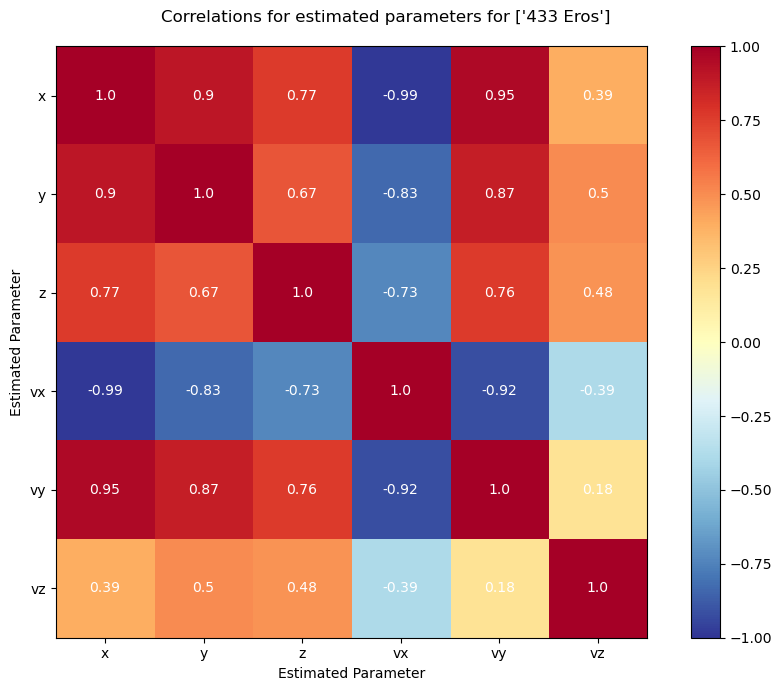

In [25]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

correlations = covariance_output.correlations
estimated_param_names = ["x", "y", "z", "vx", "vy", "vz"]


fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

fig.suptitle(f"Correlations for estimated parameters for {target_name_list}")

fig.set_tight_layout(True)

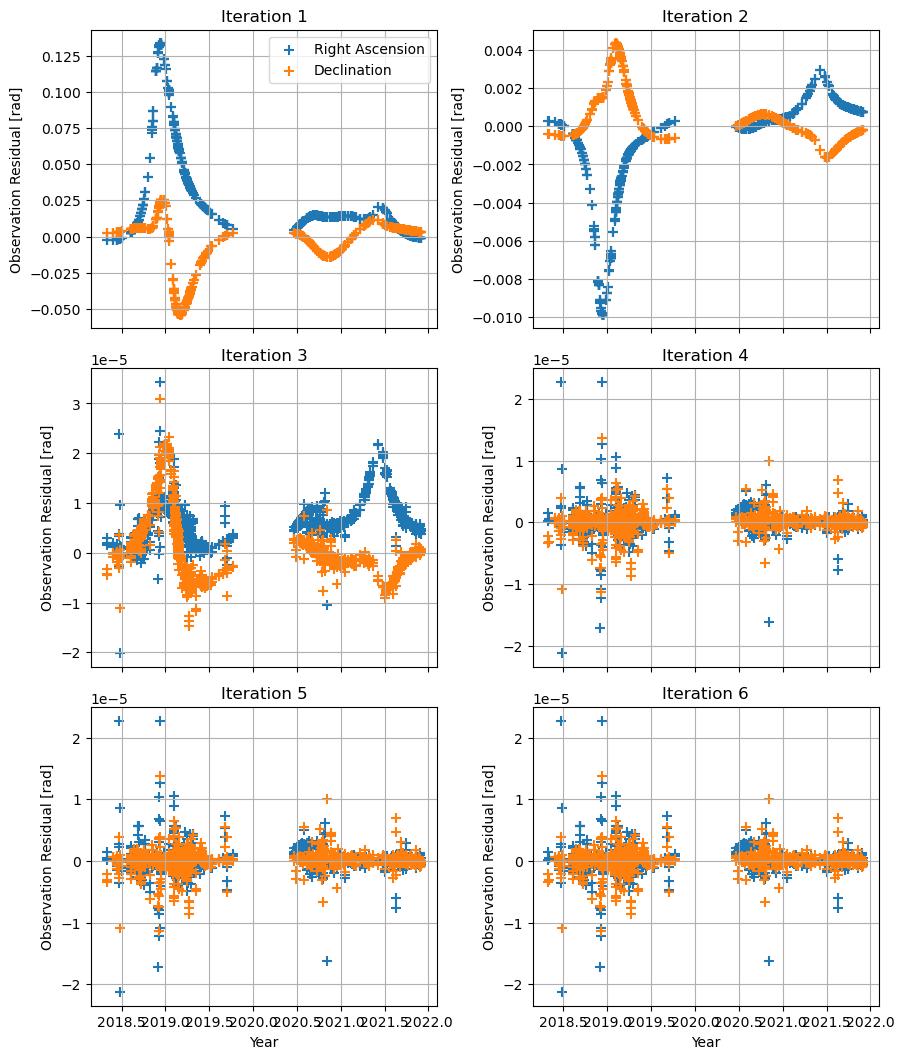

In [26]:
residual_history = pod_output.residual_history

# Number of columns and rows for our plot
number_of_columns = 2

number_of_rows = (
    int(number_of_pod_iterations / number_of_columns)
    if number_of_pod_iterations % number_of_columns == 0
    else int((number_of_pod_iterations + 1) / number_of_columns)
)

fig, axs = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(9, 3.5 * number_of_rows),
    sharex=True,
    sharey=False,
)

# We cheat a little to get an approximate year out of our times (which are in seconds since J2000)
residual_times = (
    np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000
)


# plot the residuals, split between RA and DEC types
for idx, ax in enumerate(fig.get_axes()):
    ax.grid()
    # we take every second
    ax.scatter(
        residual_times[::2],
        residual_history[
            ::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Right Ascension",
    )
    ax.scatter(
        residual_times[1::2],
        residual_history[
            1::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Declination",
    )
    ax.set_ylabel("Observation Residual [rad]")
    ax.set_title("Iteration " + str(idx + 1))

plt.tight_layout()

# add the year label for the x-axis
for col in range(number_of_columns):
    axs[int(number_of_rows - 1), col].set_xlabel("Year")

axs[0, 0].legend()

plt.show()

In [ ]:
# for spk_id, name in zip(target_spk_local_kernel, target_name_list):

#     try:
#         state = spice.get_body_cartesian_state_at_epoch(
#             spk_id,
#             global_frame_origin,
#             global_frame_orientation,
#             "NONE",
#             epoch_start_buffer
#         )
#         print(name, "OK")

#     except Exception as e:
#         print("FAILED:", name)
#         print(e)

1566 Icarus OK
66146 (1998 TU3) OK
66391 Moshup OK
437844 (1999 MN) OK
137924 (2000 BD19) OK
138127 (2000 EE14) OK
480883 (2001 YE4) OK
468468 (2004 KH17) OK
364136 (2006 CJ) OK
